# V1DD Functional Data Access

This capsule is focused on how to use the PyNWB to programmatically access data and metadata for ophys SWDB datasets. We'll explicitly show the data access patterns to load and plot data from V1DD, but many of the tools are generalizable. For more details on PyNWB, refer to the [documentation](https://pynwb.readthedocs.io/en/stable/).

In [1]:
import sys

from os.path import join as pjoin
import platform

# Add the directory for the data and utilities
mat_version = 1196

platstring = platform.platform()
system = platform.system()
if system == "Darwin":
    # macOS
    data_root = "/Volumes/Brain2026/"
elif system == "Windows":
    # Windows (replace with the drive letter of USB drive)
    data_root = "E:/"
elif "amzn" in platstring:
    # then on CodeOcean
    data_root = "/data/"
else:
    # then your own linux platform
    # EDIT location where you mounted hard drive
    data_root = "/media/$USERNAME/Brain2026/"

# Set the directory to load prepared data and utility code
data_dir = pjoin(data_root, f"v1dd_{mat_version}")
functional_dir = pjoin(data_root, f"v1dd_{mat_version}_coreg_functional_correlation")
utils_dir = pjoin("..", "utils")

# Add utilities to path
sys.path.append(utils_dir)

Example with one hard-coded session and path, to generalize later

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import hdmf
import pynwb
from hdmf_zarr import NWBZarrIO

import matplotlib.pyplot as plt
%matplotlib inline 

## Session discovery and selection

Every session is uniquely indexed by the combination of its `(column, volume)`. For this excercise we recommend using one of the sessions with meaningful amounts of coregistration

These sessions are:

> **`(column 1, volume 3)`, `(column 1, volume 5)`**

However, that is not the session ID name or load path. The `(column, volume)` information is save _within_ every NWB file. But to map between sessions, use the aggregated session index:



In [3]:
session_index = pd.read_csv(pjoin(functional_dir, "session_index.csv"))

# We can filter to only those coregistered sessions:
coreg_session_index = session_index.query('coregistered')
coreg_session_index

,path,name,format,column,volume,n_planes,session_id,coregistered
14,/data/409828_V1DD_Filtered/409828_2018-12-07_1...,409828_2018-12-07_15-05-38_filtered_2026-08-18...,zarr,2,5,6,791865124,True
22,/data/409828_V1DD_Filtered/409828_2018-12-13_1...,409828_2018-12-13_15-10-05_filtered_2026-04-09...,zarr,1,3,6,794964451,True
24,/data/409828_V1DD_Filtered/409828_2018-12-14_1...,409828_2018-12-14_14-47-35_filtered_2026-04-09...,zarr,1,5,6,795771997,True


In [133]:
# let's pull the first coregistered_session
coreg_example = 2

session_name = coreg_session_index.iloc[coreg_example]['name']
session_nwb_path = coreg_session_index.iloc[coreg_example]['path']

print(session_name, ' | ',
      f"column={coreg_session_index.iloc[coreg_example].column}, volume={coreg_session_index.iloc[coreg_example].volume}", 
      f" ({coreg_session_index.iloc[coreg_example].session_id}) ",
     )

409828_2018-12-14_14-47-35_filtered_2026-04-09_06-13-08  |  column=1, volume=5  (795771997) 


## Load the NWB file into Python

Neurodata Without Borders (NWB) files

NWB files are a standardized file format for neurophysiology data. They are formatted similarly to hdf5 containers, with data stored using using a directory format. There are "containers" (i.e. directories) that store each type of data.

The key types of data in an NWB file are:

* metadata (subject information, recording methodology, devices used, etc.)
* units and analysis tables (data for spike-sorted "units" or individual neurons)
* stimulus tables (trial information about the stimuli)
* 
The NWB files are in ZArray (Zarr) format. To load the files into Python, we'll use NWBZarrIO from hdmf_zarr, which handles Zarr objects in NWB format, like so.

In [134]:
io = NWBZarrIO(session_nwb_path, mode = 'r') 
nwbfile_zarr = io.read()

In [135]:
nwbfile_zarr

root pynwb.file.NWBFile at 0x140206488751664
Fields:
  acquisition: {
    vasculature_maps <class 'pynwb.base.Images'>
  }
  devices: {
    DEEPSCOPE <class 'pynwb.device.Device'>
  }
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  experiment_description: 2-photon imaging of column 1, volume 5
  file_create_date: [datetime.datetime(2025, 12, 15, 19, 25, 3, 979940, tzinfo=tzoffset(None, -28800))]
  identifier: 75ab6437-f8a3-4209-bd12-3fa4ff3dde98
  imaging_planes: {
    plane-0 <class 'pynwb.ophys.ImagingPlane'>,
    plane-1 <class 'pynwb.ophys.ImagingPlane'>,
    plane-2 <class 'pynwb.ophys.ImagingPlane'>,
    plane-3 <class 'pynwb.ophys.ImagingPlane'>,
    plane-4 <class 'pynwb.ophys.ImagingPlane'>,
    plane-5 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    stimulus_table <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <zarr.core.Array '/general/keywords' (4,) object read-only>
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>,
    plane-0 <class 'pynwb.base.ProcessingModule'>,
    plane-1 <class 'pynwb.base.ProcessingModule'>,
    plane-2 <class 'pynwb.base.ProcessingModule'>,
    plane-3 <class 'pynwb.base.ProcessingModule'>,
    plane-4 <class 'pynwb.base.ProcessingModule'>,
    plane-5 <class 'pynwb.base.ProcessingModule'>
  }
  session_description: V1 Deep Dive, Golden Mouse
  session_id: 795771997
  session_start_time: 2018-12-14 14:47:35-08:00
  stimulus: {
    locally_sparse_noise <class 'pynwb.base.Images'>,
    natural_images <class 'pynwb.base.Images'>,
    natural_movie <class 'pynwb.base.Images'>
  }
  subject: subject pynwb.file.Subject at 0x140206489205984
Fields:
  age: 164
  age__reference: birth
  description: Golden Mouse
  genotype: Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94
  sex: male
  species: Mus musculus
  subject_id: 409828

  timestamps_reference_time: 2018-12-14 14:47:35-08:00

The data contained in the NWB file are attributes of the nwbfile_zarr object. The data is stored as different types of objects, some specific to NWB files, such as DynamicTables.

In [136]:
## Another way to inspect the contents of the NWB file 
nwbfile_zarr.fields.keys()

dict_keys(['session_description', 'identifier', 'session_start_time', 'timestamps_reference_time', 'file_create_date', 'acquisition', 'stimulus', 'keywords', 'processing', 'devices', 'imaging_planes', 'intervals', 'subject', 'epochs', 'experiment_description', 'session_id', 'institution'])

### Cheat sheet of relevant keys

* imaging traces, per plane: `nwbfile_zarr.processing.['plane-{0}']`  
> * further subtype `.dff` and `.events` (and original .`raw` as well as each stage of processing to generate dff)  
> * roi info is in `.dff.rois`, timestamps for the data in `.dff.timestamps`, and traces in `dff.data`
> * example : `nwbfile_zarr.processing['plane-0']['dff'].data[:]`
* stimulus shown across the session in `nwbfile_zarr.intervals`
> * the windows when each stimulus were shown: `nwbfile_zarr.intervals['epochs'][:]`
> * the exact stimuls show in each temporal intervals `nwbfile_zarr.intervals['stimulus_table']`
* stimulus movies: `nwbfile_zarr.stimulus`, includes `.locally_sparse_noise`, `.natural_images`, `.natural_movie`, `.drifting_grating_full`, `.drifting_grating_windowed`  
* behavior: `nwbfile_zarr.processing.behavior` includes `.running_spped` and `.eye_tracking`
* vasculature maps: `nwbfile_zarr.acquisition`

In [159]:
nwbfile_zarr.intervals['stimulus_table']

,stim_name,start_time,stop_time,temporal_frequency,spatial_frequency,center_azimuth,center_elevation,direction,frame,image_order,image_index,stimulus_condition_id
id,,,,,,,,,,,,
0,drifting_gratings_full,52.607018,54.591988,1.0,0.08,0.0,0.0,60.0,NaN,NaN,NaN,14
1,drifting_gratings_full,55.609478,57.594498,1.0,0.04,0.0,0.0,90.0,NaN,NaN,NaN,3
2,drifting_gratings_full,58.611969,60.596958,1.0,0.04,0.0,0.0,90.0,NaN,NaN,NaN,3
3,drifting_gratings_full,61.614498,63.599457,1.0,0.08,0.0,0.0,60.0,NaN,NaN,NaN,14


## Cell activity traces

After the ROIs are extracted, the change in fluorescence over a baseline (dF/F, commonly 'dff') is calculated for each ROI. The dff is accessible as shown below.

The shape of dff is number of frames x number of rois.

In [137]:
# collect the dff form one imaging plane
plane = 0 # chosen example

dff = nwbfile_zarr.processing[f'plane-{plane}']['dff'].data

print('dff shape (nframes, nrois):',np.shape(dff))

dff shape (nframes, nrois): (21530, 193)


In [138]:
nwbfile_zarr.processing[f'plane-{plane}']

Name,/processing/plane-0/demixed/data
Type,zarr.core.Array
Data type,float32
Shape,"(21530, 193)"
Chunk shape,"(2692, 49)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,16621160 (15.9M)


In [140]:
plane_list = [0, 1, 2, 3, 4, 5]

data_list = []

for plane in plane_list:

    processing = nwbfile_zarr.processing[f'plane-{plane}']

    # Each array is frames × ROIs
    dff = processing['dff'].data[:]
    demixed = processing['demixed'].data[:]
    raw = processing['raw'].data[:]
    neuropil_corrected = processing['neuropil_corrected'].data[:]
    events = processing['events'].data[:]

    # Check that all arrays have the same dimensions
    assert dff.shape == demixed.shape == raw.shape == neuropil_corrected.shape == events.shape, \
        f"Shape mismatch in plane {plane}"

    # Create one row per ROI
    df = pd.DataFrame({
        'dff': list(dff.T),
        'demixed': list(demixed.T),
        'raw': list(raw.T),
        'neuropil_corrected': list(neuropil_corrected.T),
        'events': list(events.T),
        'plane': plane,
        'col': 1,       # HARDOCDED FOR NOW, MAYBE FIX IT OR MAKE IT BETTER
        'volume': 5,    # HARDOCDED FOR NOW, MAYBE FIX IT OR MAKE IT BETTER
    })

    # ROI ID within the plane
    df['roi'] = range(len(df))

    data_list.append(df)


# Combine all planes
dff_df = pd.concat(data_list, ignore_index=True)

print(dff_df.shape)
print(dff_df.head())

(965, 9)
                                                 dff  \
0  [0.24731265, 0.30104607, 0.3956327, -0.0099174...   
1  [0.25542, 0.19205041, 0.04985673, 0.12877543, ...   
2  [0.28504384, 0.16517459, 0.1411496, 0.13044201...   
3  [0.4600244, 0.52492607, 0.34933227, 0.27578968...   
4  [0.1826776, 0.32964945, 0.20452109, -0.0734685...   

                                             demixed  \
0  [325.14136, 350.9774, 386.4656, 299.5817, 339....   
1  [274.96048, 274.45456, 257.35178, 273.6759, 28...   
2  [298.97977, 278.5208, 281.70367, 283.38754, 27...   
3  [330.7659, 356.9791, 327.08606, 320.64197, 275...   
4  [209.54703, 238.16037, 223.60037, 198.87576, 2...   

                                                 raw  \
0  [327.23044, 354.84363, 389.214, 302.08643, 342...   
1  [274.96048, 274.45456, 257.35178, 273.6759, 28...   
2  [304.8596, 287.7915, 285.74893, 290.6936, 282....   
3  [363.8616, 383.54672, 365.5986, 354.3495, 300....   
4  [245.40541, 284.0811, 270.22296, 2

In [143]:
print(dff_df.iloc[0]['events'][:100])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.02846663
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.01622605 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.01859125]


In [141]:
dff_df.to_csv('df_dff_col1_vol5.csv', index=False)

In [144]:
# Get the roi indexing information for the example plane. Tip: this is critical for coregistering to EM structural data
roi_plane_info = nwbfile_zarr.processing[f'plane-{plane}']['dff'].rois.to_dataframe()
roi_plane_info

,column,volume,plane,roi,pika_roi_id,pika_roi_confidence,is_soma,pixel_mask
id,,,,,,,,
0,1,5,5,0,795901850_0000,0.917283,True,"[[294, 95, 1.0], [295, 95, 1.0], [296, 95, 1.0..."
1,1,5,5,1,795901850_0001,0.916786,True,"[[464, 158, 1.0], [465, 158, 1.0], [466, 158, ..."
2,1,5,5,2,795901850_0002,0.915954,True,"[[120, 351, 1.0], [121, 351, 1.0], [122, 351, ..."
3,1,5,5,3,795901850_0003,0.889593,True,"[[437, 231, 1.0], [438, 231, 1.0], [439, 231, ..."
4,1,5,5,4,795901850_0004,0.916532,True,"[[270, 273, 1.0], [271, 273, 1.0], [272, 273, ..."
...,...,...,...,...,...,...,...,...
116,1,5,5,182,795901850_0182,0.686894,True,"[[366, 366, 1.0], [367, 366, 1.0], [365, 367, ..."
117,1,5,5,207,795901850_0207,0.624195,True,"[[73, 159, 1.0], [74, 159, 1.0], [75, 159, 1.0..."
118,1,5,5,217,795901850_0217,0.807471,True,"[[295, 142, 1.0], [296, 142, 1.0], [292, 143, ..."


In [145]:
plane_list = [0, 1, 2, 3, 4, 5]
roi_info_list = []

for plane in plane_list:

    # Get ROI information for this plane
    roi_plane_info = (
        nwbfile_zarr.processing[f'plane-{plane}']['dff']
        .rois
        .to_dataframe()
    )

    # Add plane information
    roi_plane_info['plane'] = plane

    roi_info_list.append(roi_plane_info)


# Combine all planes
roi_info_df = pd.concat(
    roi_info_list,
    ignore_index=True
)

print(roi_info_df.shape)
roi_info_df.head()

(965, 8)


,column,volume,plane,roi,pika_roi_id,pika_roi_confidence,is_soma,pixel_mask
0,1,5,0,0,795901906_0000,0.916237,True,"[[248, 148, 1.0], [249, 148, 1.0], [250, 148, ..."
1,1,5,0,1,795901906_0001,0.917314,True,"[[396, 352, 1.0], [397, 352, 1.0], [398, 352, ..."
2,1,5,0,2,795901906_0002,0.916502,True,"[[474, 306, 1.0], [466, 307, 1.0], [467, 307, ..."
3,1,5,0,3,795901906_0003,0.917091,True,"[[334, 282, 1.0], [335, 282, 1.0], [336, 282, ..."
4,1,5,0,4,795901906_0004,0.917233,True,"[[211, 501, 1.0], [212, 501, 1.0], [213, 501, ..."


In [146]:
roi_info_df.to_csv('df_roi_indexing_col1_vol5.csv', index=False)
#to match ROIs to EM

In [153]:
# Get the data for one roi from one imaging plane
roi_id = 0
roi_dff = nwbfile_zarr.processing[f'plane-{plane}']['events'].data[:,roi_id]
roi_timestamp = nwbfile_zarr.processing[f'plane-{plane}']['events'].timestamps[:]
print(f'length of acquisition {len(roi_dff)}, length of timestamp {len(roi_timestamp)}')

length of acquisition 21530, length of timestamp 21530


In [154]:
roi_dff

array([0., 0., 0., ..., 0., 0., 0.], shape=(21530,), dtype=float32)

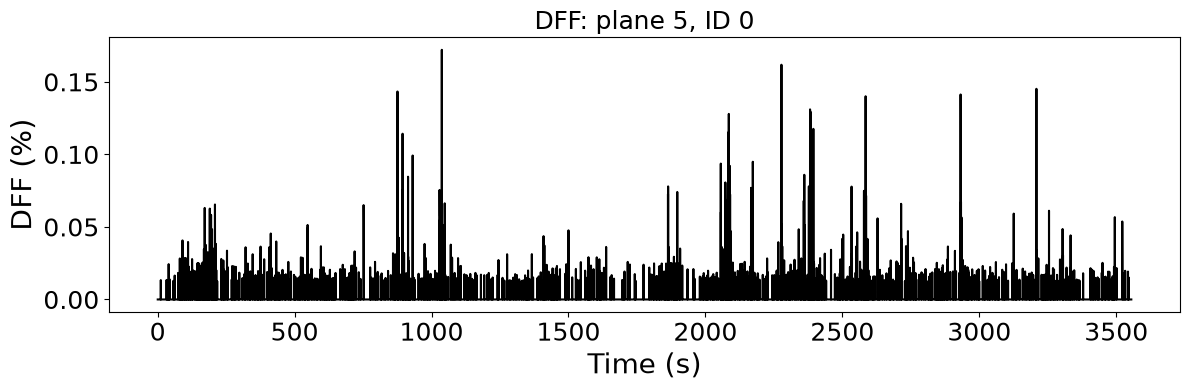

In [155]:
# Plot the dff for a single roi across the session
fig,ax = plt.subplots(figsize=(12,4))

ax.plot(roi_timestamp, roi_dff,color='k') 
        
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=18)
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=18)
ax.set_xlabel('Time (s)',fontsize=20)
ax.set_ylabel('DFF (%)',fontsize=20)
ax.set_title(f'DFF: plane {plane}, ID {roi_id}',fontsize=18)

fig.tight_layout()

In [ ]:
nwbfile_zarr.processing

Name,/processing/plane-5/demixed/data
Type,zarr.core.Array
Data type,float32
Shape,"(21379, 86)"
Chunk shape,"(5345, 22)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,7354376 (7.0M)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get all imaging planes
planes = sorted([
    key for key in nwbfile_zarr.processing.keys()
    if key.startswith('plane-')
])

all_dff = []
roi_labels = []

for plane_name in planes:

    dff = nwbfile_zarr.processing[plane_name]['dff'].data[:]
    timestamps = nwbfile_zarr.processing[plane_name]['dff'].timestamps[:]

    print(f'{plane_name}: {dff.shape}')

    # Z-score each ROI independently
    mean = np.nanmean(dff, axis=0)
    std = np.nanstd(dff, axis=0)

    dff_z = (dff - mean) / std

    # Transpose so that:
    # rows = ROIs
    # columns = time
    all_dff.append(dff_z.T)

    # Keep track of plane and ROI
    for roi_id in range(dff.shape[1]):
        roi_labels.append((plane_name, roi_id))


# Stack all ROIs from all planes
raster = np.vstack(all_dff)

print(f'Raster shape: {raster.shape}')
print(f'Number of ROIs: {raster.shape[0]}')
print(f'Number of time points: {raster.shape[1]}')


# Plot
fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(
    raster,
    aspect='auto',
    interpolation='none',
    cmap='Greys',
    extent=[
        timestamps[0],
        timestamps[-1],
        0,
        raster.shape[0]
    ],
    origin='lower'
)

ax.set_xlabel('Time (s)', fontsize=20)
ax.set_ylabel('ROI', fontsize=20)
ax.tick_params(axis='both', labelsize=16)

fig.tight_layout()

In [67]:
raster.shape

(906, 21379)

plane-0: (21379, 157)
plane-1: (21379, 162)
plane-2: (21379, 187)
plane-3: (21379, 185)
plane-4: (21379, 129)
plane-5: (21379, 86)
Raster shape: (906, 21379)
Number of ROIs: 906
Number of time points: 21379


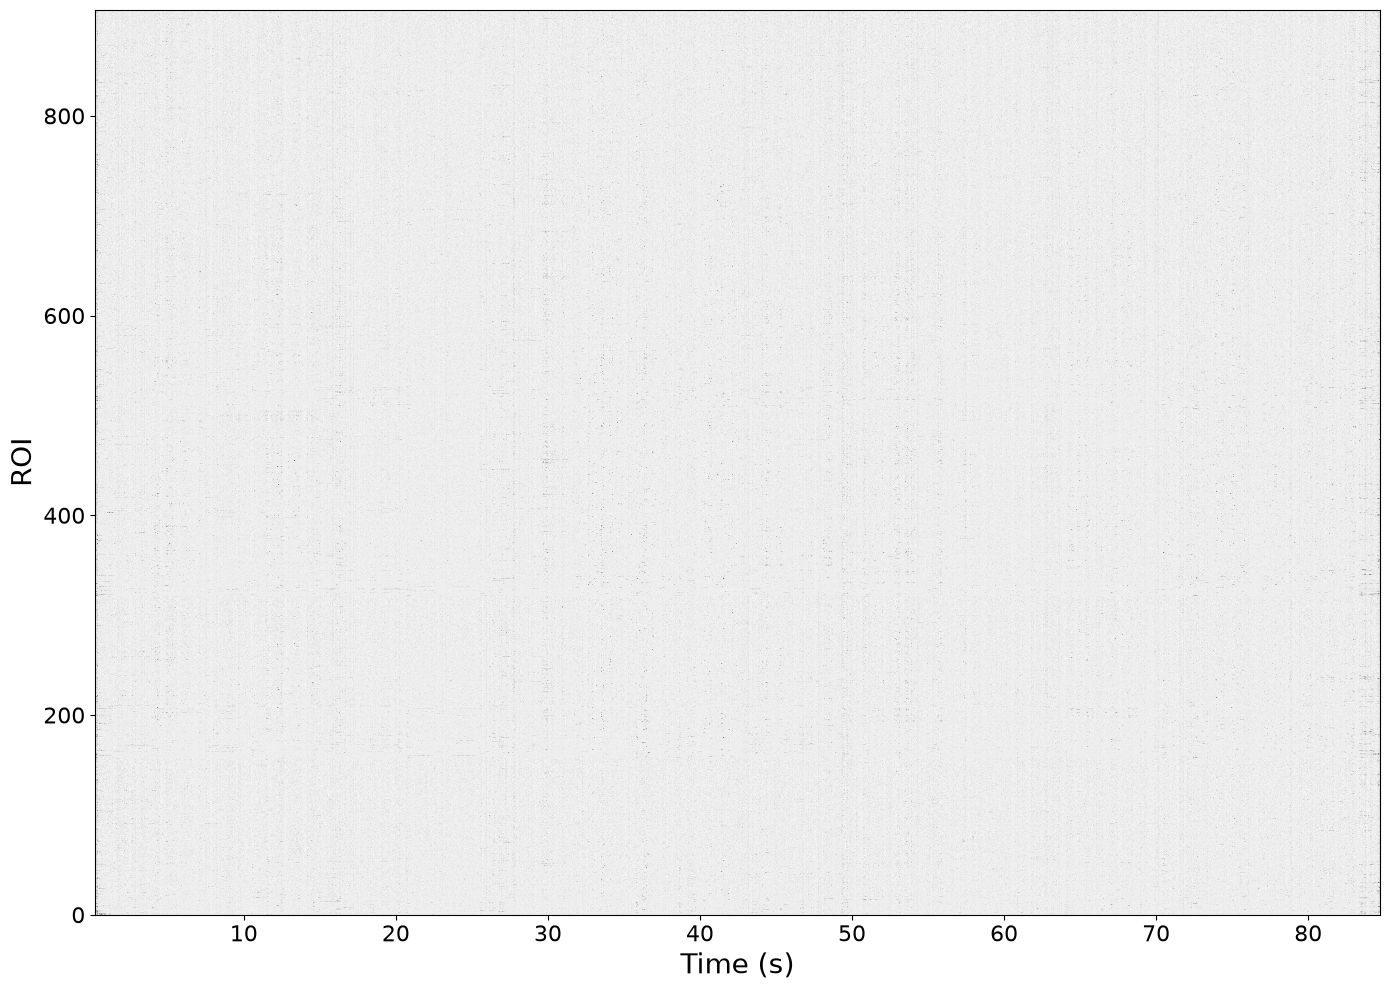

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Get all imaging planes
planes = sorted([
    key for key in nwbfile_zarr.processing.keys()
    if key.startswith('plane-')
])

all_dff = []
roi_labels = []

for plane_name in planes:

    dff = nwbfile_zarr.processing[plane_name]['dff'].data[:]
    timestamps = nwbfile_zarr.processing[plane_name]['dff'].timestamps[:]

    print(f'{plane_name}: {dff.shape}')

    # Z-score each ROI independently
    mean = np.nanmean(dff, axis=0)
    std = np.nanstd(dff, axis=0)

    dff_z = (dff - mean) / std

    # Transpose so that:
    # rows = ROIs
    # columns = time
    all_dff.append(dff_z.T)

    # Keep track of plane and ROI
    for roi_id in range(dff.shape[1]):
        roi_labels.append((plane_name, roi_id))


# Stack all ROIs from all planes
raster = np.vstack(all_dff)

print(f'Raster shape: {raster.shape}')
print(f'Number of ROIs: {raster.shape[0]}')
print(f'Number of time points: {raster.shape[1]}')


# Plot
fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(
    raster,
    aspect='auto',
    interpolation='none',
    cmap='Greys',
    extent=[
        timestamps[0],
        timestamps[500],
        0,
        raster.shape[0]
    ],
    origin='lower'
)

ax.set_xlabel('Time (s)', fontsize=20)
ax.set_ylabel('ROI', fontsize=20)
ax.tick_params(axis='both', labelsize=16)

fig.tight_layout()

In [ ]:
# Clip the color range based on percentiles
vmin = np.percentile(raster, 20)
vmax = np.percentile(raster, 99)

print(f'Color range: {vmin:.2f} to {vmax:.2f}')

fig, ax = plt.subplots(figsize=(30, 20))
# Plot epochs. 


im = ax.imshow(
    raster,
    aspect='auto',
    interpolation='none',
    cmap='Greys',
    vmin=vmin,
    vmax=vmax,
    extent=[
        timestamps[0],
        timestamps[-1],
        0,
        raster.shape[0]
    ],
    origin='lower'
)
for idx,row in epoch_table.iterrows():
    #Plot the timing of each epoch as a colored span across the x-axis
    ax.axvspan(row['start_time'],row['stop_time'],
               color=epoch_color_dict[row['stim_name']],alpha=0.3,zorder=0, label = row.stim_name)


ax.set_xlabel('Time (s)', fontsize=20)
ax.set_ylabel('ROI', fontsize=20)
ax.tick_params(axis='both', labelsize=16)

fig.tight_layout()
#fig.savefig('../scratch/raster4.png')

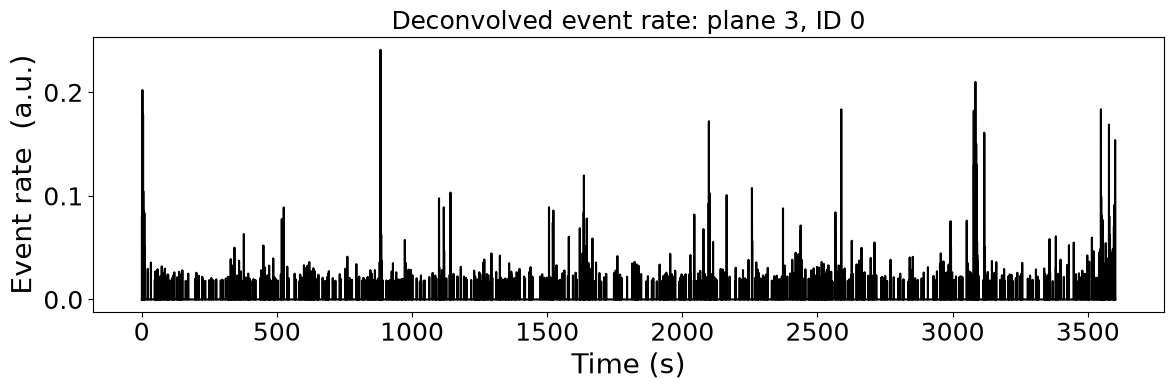

In [18]:
# Plot the dff for a single roi across the session
fig,ax = plt.subplots(figsize=(12,4))

roi_events = nwbfile_zarr.processing['plane-5']['events'].data[:,roi_id]
ax.plot(roi_timestamp, roi_events,color='k') 
        
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=18)
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=18)
ax.set_xlabel('Time (s)',fontsize=20)
ax.set_ylabel('Event rate  (a.u.)',fontsize=20)
ax.set_title(f'Deconvolved event rate: plane {plane}, ID {roi_id}',fontsize=18)

fig.tight_layout()

## Epoch Table

The epoch table contains the start and stop times/frames for each stimulus epoch. You can use the epoch table with the dff array to pull and compare neural activity across different stimulus epochs.

In [156]:
epoch_table = nwbfile_zarr.intervals['epochs'].to_dataframe()
epoch_table

,stim_name,start_time,stop_time,duration
id,,,,
0,drifting_gratings_full,52.607018,339.829407,287.222382
1,drifting_gratings_windowed,342.848602,630.071167,287.222565
2,locally_sparse_noise,633.090332,873.307068,240.216736
3,spontaneous,874.291260,1174.524658,300.233398
4,natural_images_12,1177.543823,1329.653809,152.109985
5,natural_movie,1341.680420,1792.038818,450.358398
6,locally_sparse_noise,1796.092163,2096.208740,300.116577
7,natural_images,2098.310547,2397.476318,299.165771
8,drifting_gratings_windowed,2412.572266,2699.811523,287.239258


In [149]:
epoch_table.to_csv('df_epochs_col1_vol5.csv', index=False)

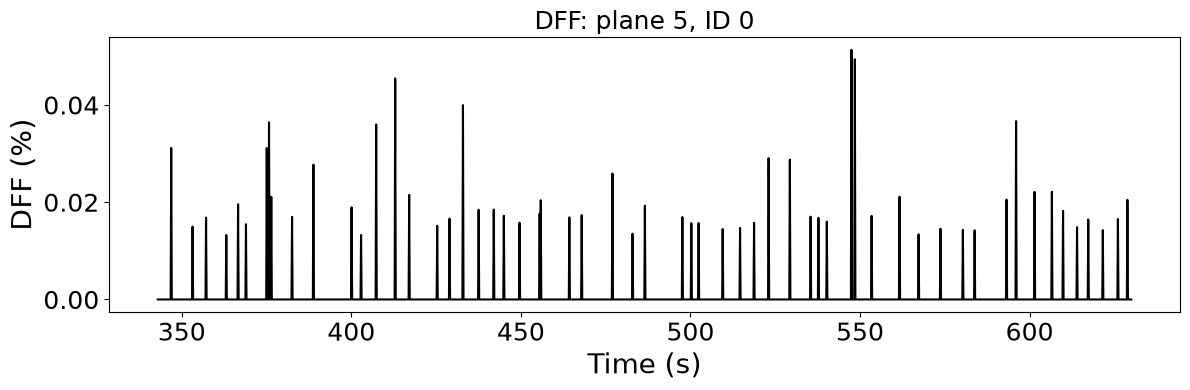

In [157]:
# filter to example stimulus epoch
epoch_id =  1# iterate through
filtered_time_index =(roi_timestamp > epoch_table.iloc[epoch_id].start_time) & (roi_timestamp <= epoch_table.iloc[epoch_id].stop_time)

# Plot the dff for a single roi across the session
fig,ax = plt.subplots(figsize=(12,4))

ax.plot(roi_timestamp[filtered_time_index], roi_dff[filtered_time_index],color='k') 
        
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=18)
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=18)
ax.set_xlabel('Time (s)',fontsize=20)
ax.set_ylabel('DFF (%)',fontsize=20)
ax.set_title(f'DFF: plane {plane}, ID {roi_id}',fontsize=18)

fig.tight_layout()

The epoch table reports the start and stop times for each stimulus epoch in the session. We can overlay the epochs with our plot of neural activity to compare how the firing rate changes in each epoch.

In [57]:
epoch_table.stim_name.unique()

array(['drifting_gratings_full', 'drifting_gratings_windowed',
       'locally_sparse_noise', 'spontaneous', 'natural_images_12',
       'natural_movie', 'natural_images'], dtype=object)

In [58]:
# Make a color dictionary to identify stimulus epochs
category_colors = {
    'spontaneous': '#c49cde',  # purple-ish
    'drifting_gratings_full':   '#a9d39e',  # green-ish
    'drifting_gratings_windowed':   '#a9d39e',  # green-ish
    'locally_sparse_noise': '#aee6ed',  # cyan-ish
    'natural_movie':   '#f4a582',   # orange-ish
    'natural_images':   '#F8FCC0',   # yellow-ish
    'natural_images_12':   '#F8FCC0',   # yellow-ish
}

epoch_color_dict = {row.stim_name: category_colors[row.stim_name]
              for row in epoch_table.itertuples(index=False)}

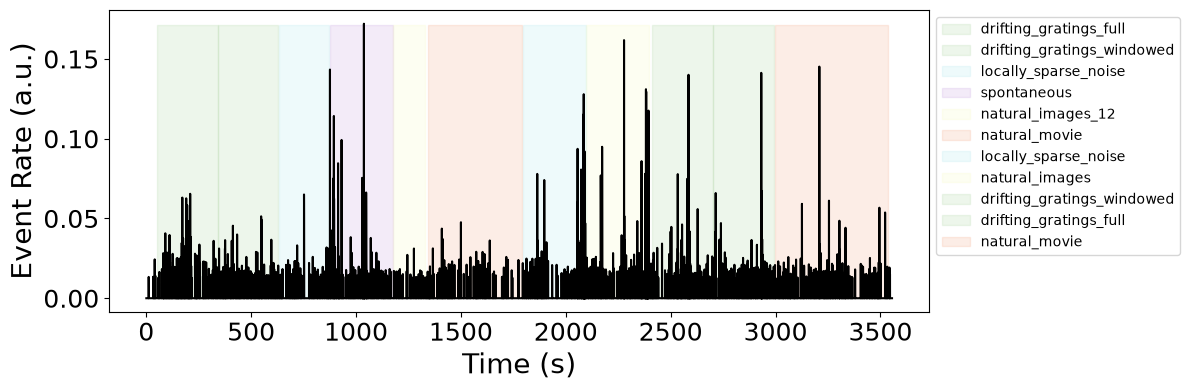

In [158]:
# Plot the events for a single unit across the session with epochs overlaid 

fig,ax = plt.subplots(figsize=(12,4))

# Plot events
roi_events = nwbfile_zarr.processing['plane-5']['events'].data[:,roi_id]
ax.plot(roi_timestamp, roi_events,color='k') 

# Plot epochs. 
for idx,row in epoch_table.iterrows():
    #Plot the timing of each epoch as a colored span across the x-axis
    ax.axvspan(row['start_time'],row['stop_time'],0.05,0.95,
               color=epoch_color_dict[row['stim_name']],alpha=0.2,zorder=0, label = row.stim_name)

ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=18)
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=18)
ax.set_xlabel('Time (s)',fontsize=20)
ax.set_ylabel('Event Rate (a.u.)',fontsize=20)
ax.legend(bbox_to_anchor=(1.0, 1.0))

fig.tight_layout()

## Behavior

While recorded, mice could move freely on a wheel. Let's overlay run speed to the activity of one neuron, then to the population average

In [18]:
nwbfile_zarr.processing['behavior']['running_speed']

Name,/processing/behavior/running_speed/data
Type,zarr.core.Array
Data type,float32
Shape,"(209040,)"
Chunk shape,"(52260,)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,836160 (816.6K)


In [19]:
runspeed_array = nwbfile_zarr.processing['behavior']['running_speed'].data[:]

runspeed_timestamp = nwbfile_zarr.processing['behavior']['running_speed'].timestamps[:]
print(f'length of behavior trace {len(runspeed_array)}, length of behavior timestamp {len(runspeed_timestamp)}')

# Note: this is different time basis and resolution of sampling to the imaging
print(f'length of imaging acquisition {len(roi_dff)}, length of ROI timestamp {len(roi_timestamp)}')

length of behavior trace 209040, length of behavior timestamp 209040
length of imaging acquisition 21379, length of ROI timestamp 21379


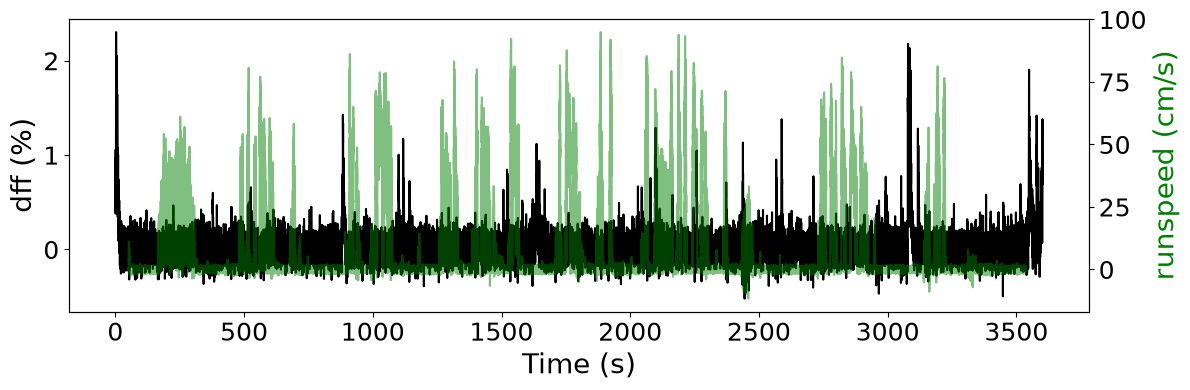

In [20]:
fig,ax = plt.subplots(figsize=(12,4))

# Plot events
ax.plot(roi_timestamp, roi_dff, color='k', label=None) 

ax2 = ax.twinx()
ax2.plot(runspeed_timestamp, runspeed_array, color='g',label=None, alpha=0.5) 

ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=18)
ax2.tick_params(axis='y',which='major',labelsize=18)
ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=18)
ax.set_xlabel('Time (s)',fontsize=20)
ax.set_ylabel('dff (%)',fontsize=20)
ax2.set_ylabel('runspeed (cm/s)',fontsize=20,color='g')
# ax.legend(bbox_to_anchor=(1.0, 1.0))

fig.tight_layout()